## import

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')
from ult import *
from irc_gym.irc.model import FuncBeliefModel
from stable_baselines3 import PPO
from auditoryforage.AF_env import AuditoryForagingReward2 as AFR2


## train

food reard list:  ['10', '2508', '5005', '7502', '10000']


/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


ycstore/seed_0_varynode_40_epoch_0


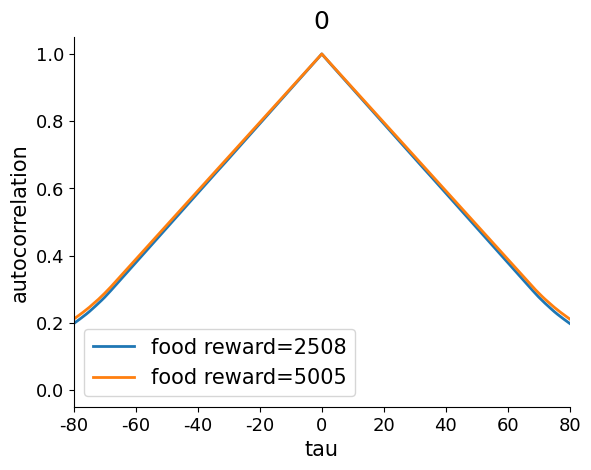

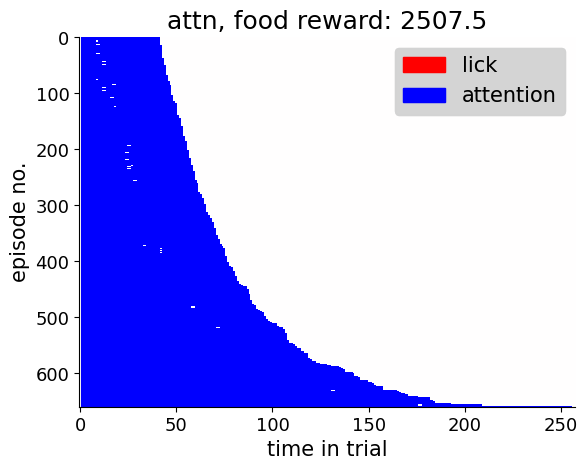

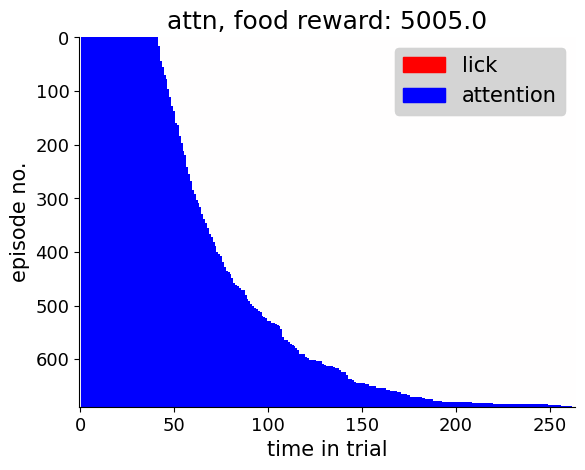

ycstore/seed_0_varynode_40_epoch_1


/Users/yc/repo/auditory-foraging-IRC/ult.py:560: RuntimeWarning: invalid value encountered in divide
  autocorr /= np.max(autocorr)


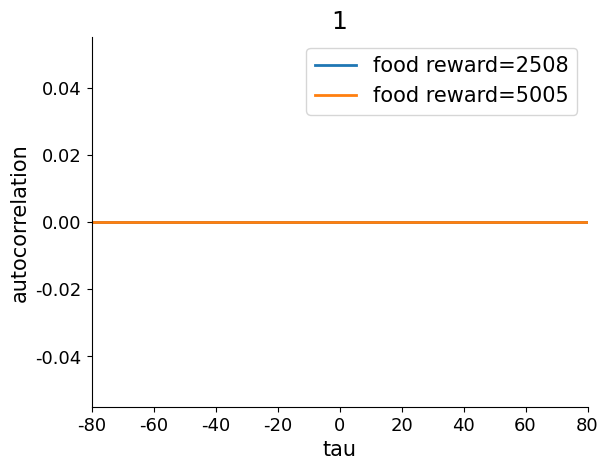

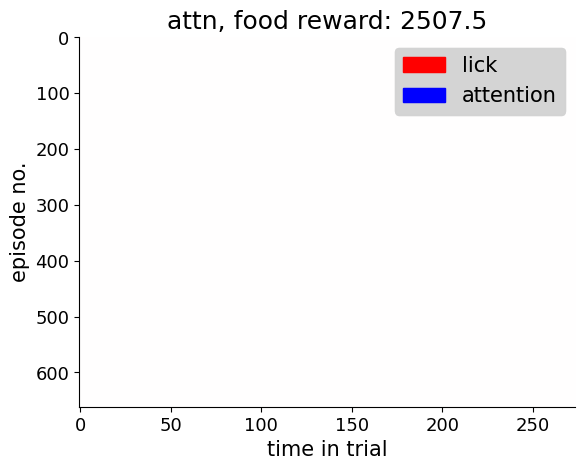

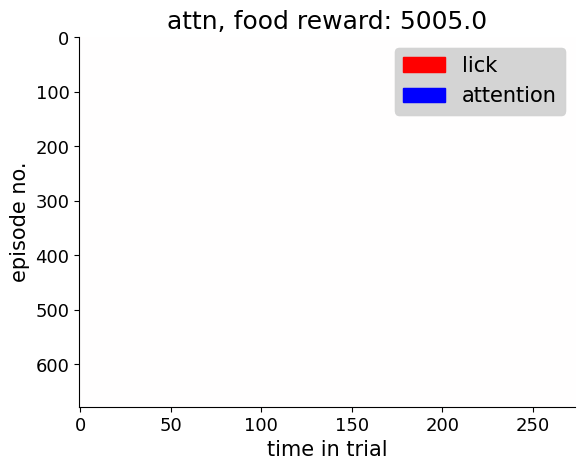

ycstore/seed_0_varynode_40_epoch_2


/Users/yc/repo/auditory-foraging-IRC/ult.py:560: RuntimeWarning: invalid value encountered in divide
  autocorr /= np.max(autocorr)


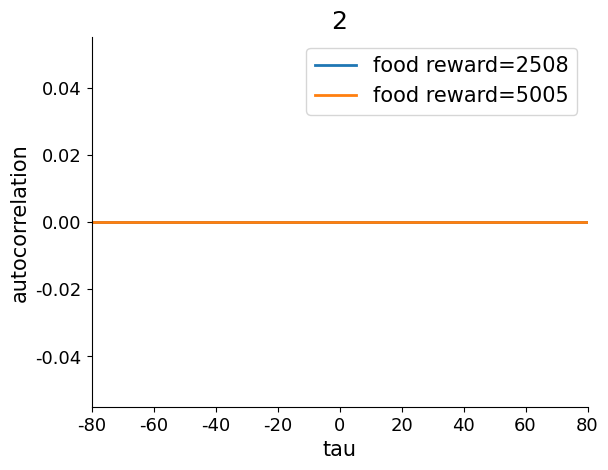

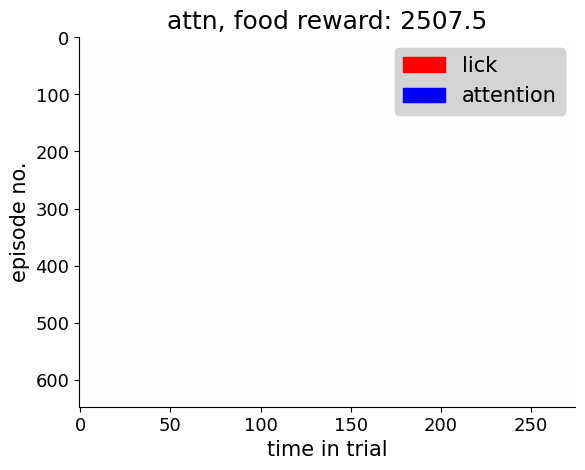

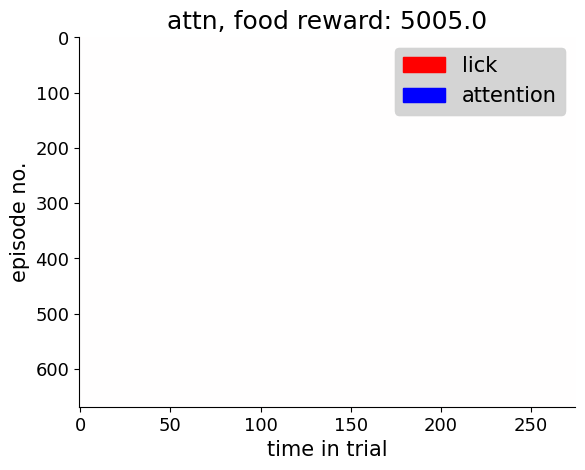

ycstore/seed_0_varynode_40_epoch_3


/Users/yc/repo/auditory-foraging-IRC/ult.py:560: RuntimeWarning: invalid value encountered in divide
  autocorr /= np.max(autocorr)


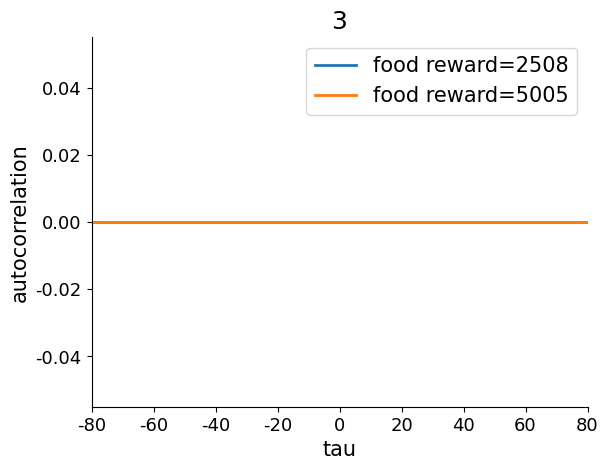

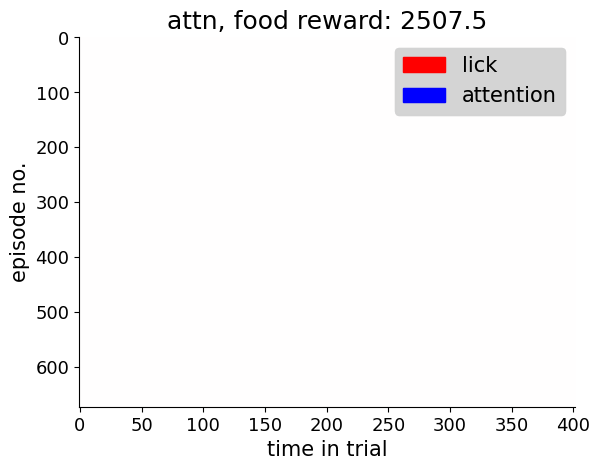

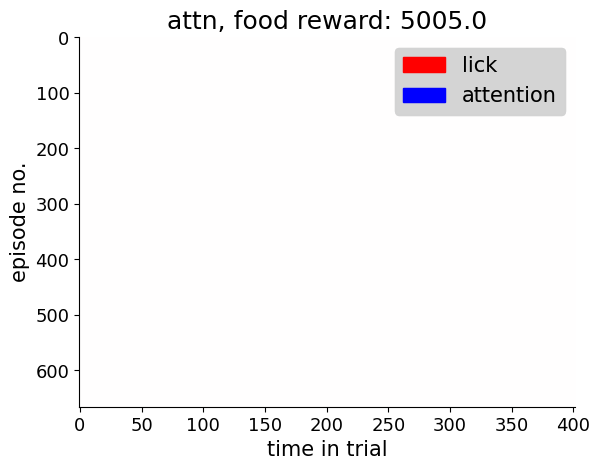

ycstore/seed_0_varynode_40_epoch_4


/Users/yc/repo/auditory-foraging-IRC/ult.py:560: RuntimeWarning: invalid value encountered in divide
  autocorr /= np.max(autocorr)


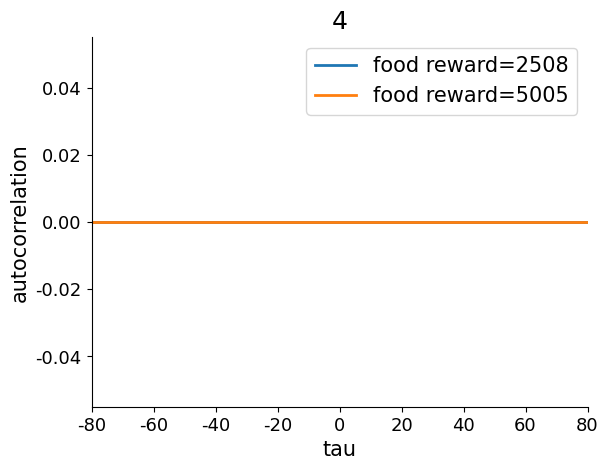

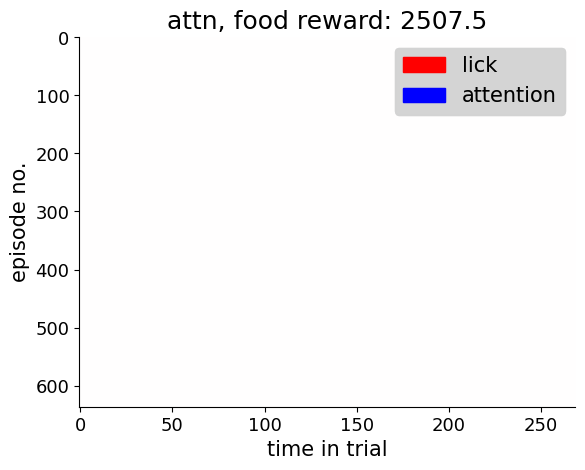

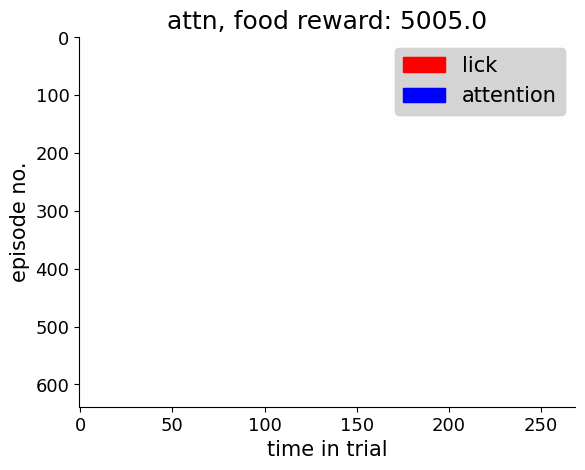

ycstore/seed_0_varynode_40_epoch_5


/Users/yc/repo/auditory-foraging-IRC/ult.py:560: RuntimeWarning: invalid value encountered in divide
  autocorr /= np.max(autocorr)


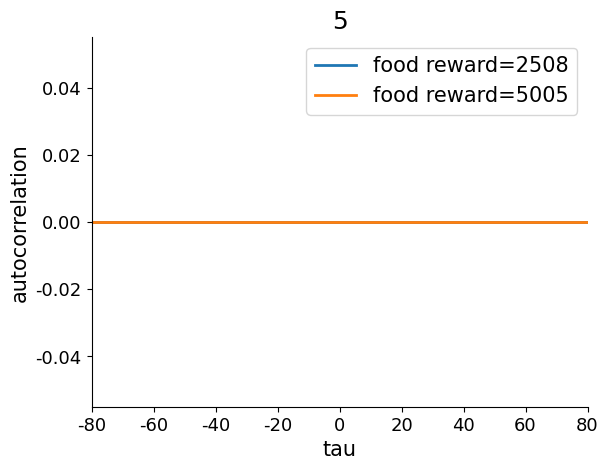

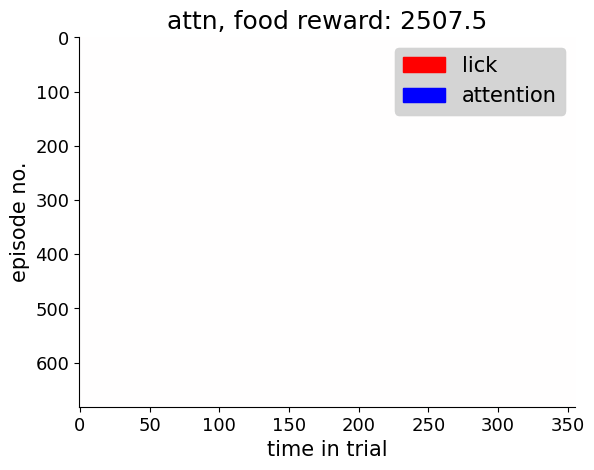

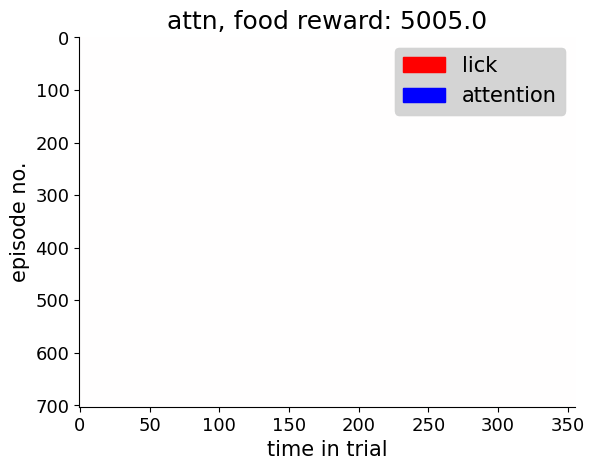

ycstore/seed_0_varynode_40_epoch_6


/Users/yc/repo/auditory-foraging-IRC/ult.py:560: RuntimeWarning: invalid value encountered in divide
  autocorr /= np.max(autocorr)


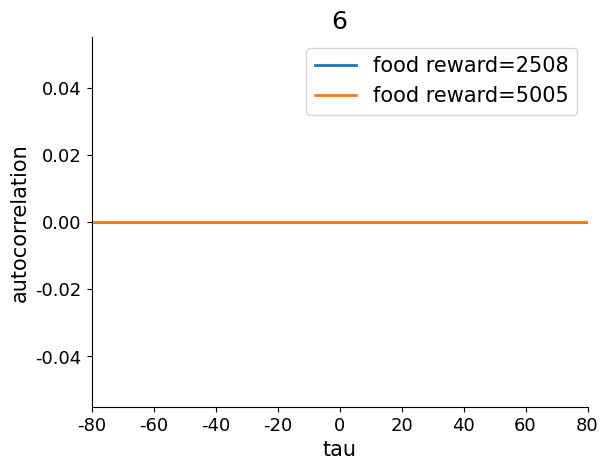

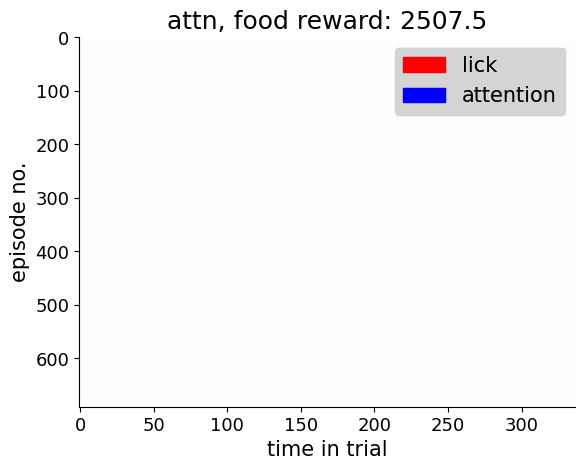

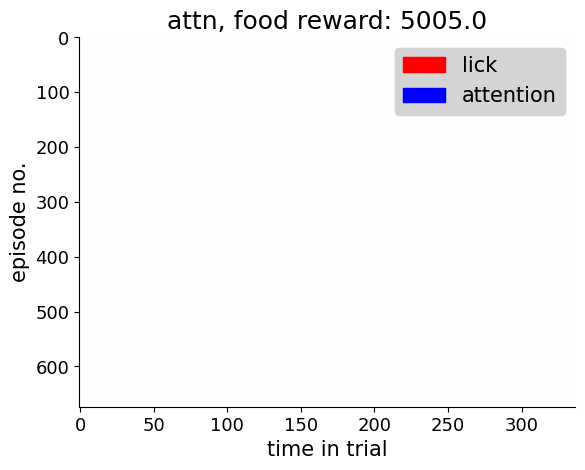

ycstore/seed_0_varynode_40_epoch_7


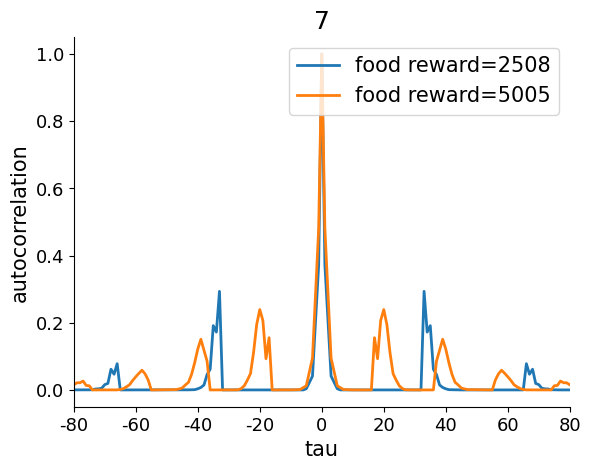

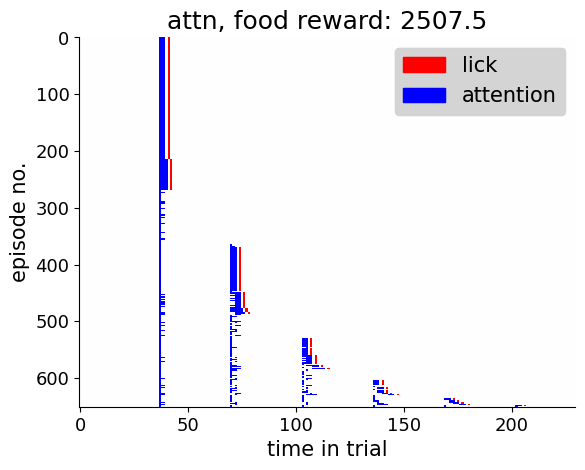

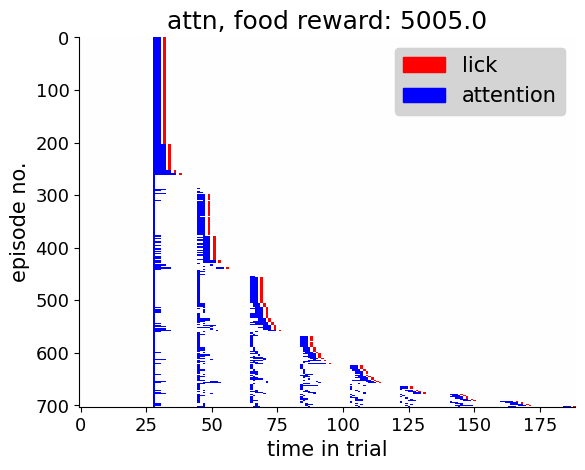

ycstore/seed_0_varynode_40_epoch_8


KeyboardInterrupt: 

In [4]:
modelname = 'varynode'
# training hyper params
epoch_size = 33333
n_epoch = 55
n_seed = 1
seed = 0
no_episodes = 3333  # for eval plot during training
plot_no_episodes = 3333
vmin, vmax = 10, 10000
food_reward_list = np.linspace(vmin, vmax, 5)
print('food reard list: ', [f'{a:.0f}' for a in food_reward_list])

for attcost in [-1.6]:
    for facost in [-50,]:
        for node in [40]:
            env_param = [0, None, attcost, .25, facost, 0, 0]
            thismodel = f'seed_{seed}_{modelname}_{node}'


            np.random.seed(seed)
            task = AFR2(spec={'agent':
                                {'lick_cost': env_param[0],
                                'food_reward': env_param[1],
                                'attention_cost_coeff': env_param[2],
                                'attention_cost_temp': env_param[3],
                                'penalty_cost': env_param[4],
                                'iti_cost': env_param[5],
                                'time_in_game_reward': env_param[6]},
                                'experiment': {'no_signal_nodes': node}})
            task.food_reward_list = food_reward_list
            taskbelief = FuncBeliefModel(env=task, rng=1)
            task.obs_certainity_possible = np.array([.5, .7])
            model = PPO('MlpPolicy', taskbelief, verbose=0, device='cpu',
                        clip_range=0.1, ent_coef=0.01, tensorboard_log=f"runs/{modelname}",)

            for i in range(n_epoch):
                # train
                model.learn(total_timesteps=epoch_size,
                            tb_log_name=thismodel,
                            reset_num_timesteps=False,
                            )
                model.save(f'ycstore/{thismodel}_epoch_{i}')
                print(f'ycstore/{thismodel}_epoch_{i}')

                # eval
                def eval_wrapper(a):
                    episode = run_one_episode(task=task, taskbelief=taskbelief, agent=model,
                                                num_steps=100000, deterministic=True)
                    return episode

                with multiprocess.Pool(processes=6) as pool:
                    all_episode_data = pool.map(
                        eval_wrapper, range(no_episodes))

                all_reward_res = {}  # k: v = foodreward idx: this food reward res
                for r in range(len(food_reward_list)):
                    attention_prob_list, lick_prob_list, noise_prob_list, lick_time_list, att_time_list, trial_len = [], [], [], [], [], []
                    all_reward_res[r] = attention_prob_list, lick_prob_list, noise_prob_list, lick_time_list, att_time_list, trial_len

                for episode in all_episode_data:
                    attention_prob_list, lick_prob_list, noise_prob_list, lick_time_list, att_time_list, trial_len = all_reward_res[
                        episode['trial_food_reward_idx']]
                    att_time_list.append(
                        np.where(np.array([elt[1] for elt in episode['actions']]) == 1)[0])
                    if episode['actions'][-1][0] == 1:
                        lick_time_list.append(len(episode['states']))
                    else:
                        lick_time_list.append(None)
                    trial_len.append(len(episode['actions']))

                # auto correlation
                for food_reward_idx in list(all_reward_res.keys())[1:3]:
                    att_seq_list = []
                    for episode in all_episode_data:
                        if episode['trial_food_reward_idx'] == food_reward_idx:
                            att_seq_list.append(
                                [float(elt[1]) for elt in episode['actions']])
                    # Sorting based on increasing trial length
                    sorted_list_of_lists = sorted(att_seq_list, key=len)
                    # Choosing what range of trial lengths to use. Could modify to be more consistent.
                    sequences = sorted_list_of_lists[-333:-1]
                    normalized_sequences = []
                    max_length = 0
                    for sequence in sequences:
                        normalized_seq = np.array(sequence)
                        if not np.isnan(normalized_seq.any()):
                            normalized_sequences.append(normalized_seq)
                            max_length = max(
                                max_length, len(normalized_seq))

                    padded_sequences = []
                    for seq in normalized_sequences:
                        padded_seq = np.pad(
                            seq, (0, max_length - len(seq)), mode='constant')
                        padded_sequences.append(padded_seq)

                    autocorrelation_sum = np.zeros(2 * max_length - 1)
                    for seq in padded_sequences:
                        autocorrelation_sum += np.nan_to_num(
                            compute_autocorrelation(seq), nan=0)

                    average_autocorrelation = autocorrelation_sum / \
                        len(padded_sequences)
                    xs = np.arange(0, len(average_autocorrelation), 1)
                    xs = xs-len(xs)//2
                    plt.plot(xs, average_autocorrelation,
                                label=f'food reward={food_reward_list[food_reward_idx]:.0f}')
                    plt.xlabel('tau')
                    plt.ylabel('autocorrelation')
                    plt.title(f'{i}')
                    plt.xlim(-80, 80)
                plt.legend()
                quicksave('autocorr', modelname)
                plt.show()

                # heatmap trial indicator (att and lick)
                for food_reward_idx in list(all_reward_res.keys())[1:3]:
                    attention_prob_list, lick_prob_list, noise_prob_list, lick_time_list, att_time_list, trial_len = all_reward_res[
                        food_reward_idx]
                    sortind = np.argsort(trial_len[:plot_no_episodes])

                    grid = np.zeros((plot_no_episodes, max(trial_len)+2))
                    # att
                    plot_data = att_time_list[:plot_no_episodes]
                    for i, arr in enumerate(plot_data):
                        grid[i, arr] = -1

                    # lick
                    plot_data = lick_time_list[:plot_no_episodes]
                    for i, arr in enumerate(plot_data):
                        if arr:
                            grid[i, arr] = 1

                    plt.figure()
                    c = plt.imshow(grid[sortind], cmap='bwr', vmin=-1, vmax=1,
                                    aspect='auto', interpolation='none')
                    # plt.colorbar(c)
                    plt.xlabel('time in trial')
                    plt.ylabel('episode no.')
                    plt.title(
                        f'attn, food reward: {food_reward_list[food_reward_idx]}')

                    # legend
                    # Create Patch objects for the custom legend
                    red_patch = Patch(color='red', label='lick')
                    blue_patch = Patch(color='blue', label='attention')
                    # Create a new legend
                    extra_legend = plt.legend(
                        handles=[red_patch, blue_patch], loc='upper right', frameon=True)
                    frame = extra_legend.get_frame()
                    frame.set_color('lightgrey')
                    # Add the new legend to the existing plot
                    plt.gca().add_artist(extra_legend)
                    quicksave(f'ep indicator {food_reward_idx}', modelname)
                    plt.show()

            notify(f'training {thismodel} finished')

# eval

ycstore/seed_0_varynode_10_epoch_51
ycstore/seed_0_varynode_25_epoch_51
ycstore/seed_0_varynode_40_epoch_51


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


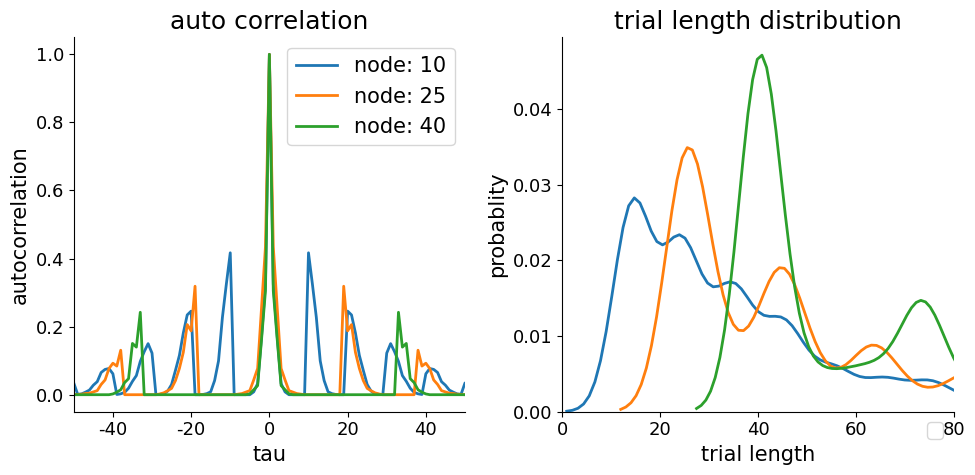

ycstore/seed_0_varynode_10_epoch_51
ycstore/seed_0_varynode_25_epoch_51
ycstore/seed_0_varynode_40_epoch_51


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


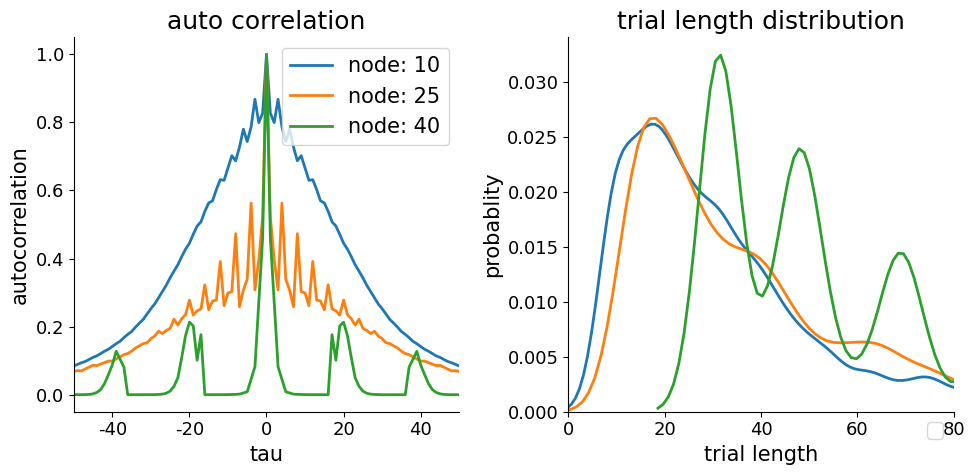

In [26]:

modelname = 'varynode'
# training hyper params
epoch_size = 33333
n_epoch = 55
n_seed = 1
modeli = 0
vmin, vmax = 10, 10000
food_reward_list = np.linspace(vmin, vmax, 5)
no_episodes=3333

for i in range(51,52): # many plots for each epoch
    for food_reward_idx in [1,2]: # one plot
            fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,5))
            
            # autocorr. 
            for node in [10,25,40]: # one line
                env_param = [0, None, attcost, .25, facost, 0, 0]
                seed=0
                thismodel = f'seed_0_{modelname}_{node}'
                np.random.seed(seed)
                task = AFR2(spec={'agent': 
                                                    {'lick_cost': env_param[0],
                                                    'food_reward': env_param[1],
                                                    'attention_cost_coeff': env_param[2],
                                                    'attention_cost_temp': env_param[3],
                                                    'penalty_cost': env_param[4],
                                                    'iti_cost': env_param[5],
                                                    'time_in_game_reward': env_param[6]},
                                            'experiment':{                              'no_signal_nodes':node}})
                task.food_reward_list = food_reward_list
                taskbelief = FuncBeliefModel(env=task, rng=1)
                task.obs_certainity_possible = np.array([.5,.7])
        
                # eval
                model = PPO.load(f'ycstore/{thismodel}_epoch_{i}')
                print(f'ycstore/{thismodel}_epoch_{i}')
                
                def eval_wrapper(a):
                    episode = run_one_episode(task=task, taskbelief=taskbelief, agent=model,
                                            num_steps=100000, deterministic=True)
                    return episode

                with multiprocess.Pool(processes=6) as pool:
                    all_episode_data = pool.map(eval_wrapper, range(no_episodes))

                all_reward_res={} # k: v = foodreward idx: this food reward res
                for r in range(len(food_reward_list)):
                    attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=[],[],[],[],[],[]
                    all_reward_res[r]=attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len

                for episode in all_episode_data:
                    attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=all_reward_res[episode['trial_food_reward_idx']]
                    att_time_list.append(
                        np.where(np.array([elt[1] for elt in episode['actions']]) == 1)[0])
                    if episode['actions'][-1][0] == 1:
                        lick_time_list.append(len(episode['states']))
                    else:
                        lick_time_list.append(None)
                    trial_len.append(len(episode['actions']))

                # auto correlation 
                att_seq_list = []
                for episode in all_episode_data:
                    if episode['trial_food_reward_idx']==food_reward_idx:
                        att_seq_list.append([float(elt[1]) for elt in episode['actions']])
                # Sorting based on increasing trial length
                sorted_list_of_lists = sorted(att_seq_list, key=len)
                sequences = sorted_list_of_lists[-333:-1] # Choosing what range of trial lengths to use. Could modify to be more consistent.
                normalized_sequences = []
                max_length = 0
                for sequence in sequences:
                    normalized_seq = np.array(sequence)
                    if not np.isnan(normalized_seq.any()):
                        normalized_sequences.append(normalized_seq)
                        max_length = max(max_length, len(normalized_seq))    
                    
                padded_sequences = []
                for seq in normalized_sequences:
                    padded_seq = np.pad(seq, (0, max_length - len(seq)), mode='constant')
                    padded_sequences.append(padded_seq)

                autocorrelation_sum = np.zeros(2 * max_length - 1)
                for seq in padded_sequences:
                    autocorrelation_sum += np.nan_to_num(compute_autocorrelation(seq), nan=0)

                average_autocorrelation = autocorrelation_sum / len(padded_sequences)
                xs=np.arange(0,len(average_autocorrelation),1)
                xs=xs-len(xs)//2
                ax1.plot(xs,average_autocorrelation,label=f'node: {node}')
                ax1.set_xlabel('tau')
                ax1.set_ylabel('autocorrelation')
                ax1.set_xlim(-50,50)
                # ax1.set_title(f'food reward={food_reward_list[food_reward_idx]:.0f} epoch:{i}')
                ax1.set_title('auto correlation')
                ax1.legend()

                # ax2.hist([len(a) for a in att_seq_list])
                sns.kdeplot([len(a) for a in att_seq_list], fill=False, bw_adjust=0.5)
                ax2.set_xlabel('trial length')
                ax2.set_ylabel('probablity')
                ax2.set_xlim(0,80)
                ax2.set_title('trial length distribution')
                # ax2.set_title(f'food reward={food_reward_list[food_reward_idx]:.0f} epoch:{i}')


            plt.legend(bbox_to_anchor=(1,0))
            plt.tight_layout()
            quicksave('autocorr', modelname)
            plt.show()
